# Package

In [24]:
# ============================================================
# Standard library
# ============================================================

import os
from dataclasses import dataclass
from typing import Callable, Dict, Any, Optional, Iterable, List, Tuple

from dateutil.relativedelta import relativedelta


# ============================================================
# Core scientific stack
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# Machine Learning
# ============================================================

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import ParameterGrid, ParameterSampler
from sklearn.metrics import mean_absolute_error

from lightgbm import LGBMRegressor


# ============================================================
# Forecasting
# ============================================================

from mlforecast import MLForecast
from mlforecast.utils import PredictionIntervals


# ============================================================
# Explainability
# ============================================================

import shap


# ============================================================
# Experiment tracking
# ============================================================

import mlflow


# ============================================================
# Local project utilities
# ============================================================

from utils_true import (
    load_wide_from_feast,
    make_ts_from_wide,
    ModelSpec,
    run_backtesting_generic,
    prepare_backtest_partitions,
    compute_explainability_by_partition,
    build_score_and_explainability_tables,
    log_matplotlib_figure_to_mlflow,
    save_and_log_matplotlib_figure,
    log_experiment_runs_to_mlflow,
    import_mlflow_experiment,
    build_models_and_X_for_functional_plots,
)

from utils_functional_plots import (
    build_functional_inputs_from_meta,
    plot_functional_grid,
)

# Parameters

## Data parameters

In [25]:
series_ids = [
    "BUSLOANS","CPIAUCSL","DPCERA3M086SBEA","INDPRO",
    "M2SL","OILPRICEX","RPI","SP500","TB3MS","UNRATE","USREC",
]

START = "1960-01-01"
END   = "2025-08-01"

LAGS = 12

In [26]:
df_wide = load_wide_from_feast(
    feature_ref="stationary_value:value",   
    series_ids=series_ids,
    start=START,
    end=END,
    freq="MS",
)

display(df_wide.head())

Using date as the event timestamp. To specify a column explicitly, please name it event_timestamp.


series_id,BUSLOANS,CPIAUCSL,DPCERA3M086SBEA,INDPRO,M2SL,OILPRICEX,RPI,SP500,TB3MS,UNRATE,USREC
date,,,,,,,,,,,
1960-01-01,0.011578,-0.006156,0.001204,0.091976,0.001323,0.0,0.020977,0.017909,0.30,-0.8,0.0
1960-02-01,0.011905,-0.003767,0.006009,0.076960,0.002007,0.0,0.014565,-0.025663,-0.19,-1.1,0.0
1960-03-01,-0.008356,-0.005455,0.021240,0.007959,0.001324,0.0,0.006250,-0.070857,-1.18,-0.2,0.0
1960-04-01,-0.009098,0.005090,0.033752,-0.025916,0.000634,0.0,0.006489,-0.040442,-1.12,0.0,0.0
1960-05-01,-0.000359,0.003383,0.009040,-0.018119,0.003977,0.0,0.007747,-0.010090,-0.67,0.0,1.0


In [27]:
ts_df, exog_cols = make_ts_from_wide(
    df_wide=df_wide,
    target_col="UNRATE",
    lags=LAGS,
    include_target_lags=False,
)

print("ts_df shape:", ts_df.shape)
display(ts_df.head(15))

print("n exog cols:", len(exog_cols))
print("exog_cols:", exog_cols)

ts_df shape: (776, 13)


series_id,unique_id,ds,y,BUSLOANS_lag12,CPIAUCSL_lag12,DPCERA3M086SBEA_lag12,INDPRO_lag12,M2SL_lag12,OILPRICEX_lag12,RPI_lag12,SP500_lag12,TB3MS_lag12,USREC_lag12
0,UNRATE,1961-01-01,1.4,0.011578,-0.006156,0.001204,0.091976,0.001323,0.0,0.020977,0.017909,0.30,0.0
1,UNRATE,1961-02-01,2.1,0.011905,-0.003767,0.006009,0.076960,0.002007,0.0,0.014565,-0.025663,-0.19,0.0
2,UNRATE,1961-03-01,1.5,-0.008356,-0.005455,0.021240,0.007959,0.001324,0.0,0.006250,-0.070857,-1.18,0.0
3,UNRATE,1961-04-01,1.8,-0.009098,0.005090,0.033752,-0.025916,0.000634,0.0,0.006489,-0.040442,-1.12,0.0
4,UNRATE,1961-05-01,2.0,-0.000359,0.003383,0.009040,-0.018119,0.003977,0.0,0.007747,-0.010090,-0.67,1.0
5,UNRATE,1961-06-01,1.5,0.014620,0.006777,-0.005299,-0.021751,0.004949,0.0,0.006634,0.039906,-0.85,1.0
6,UNRATE,1961-07-01,1.5,-0.000611,-0.005433,-0.018541,-0.017271,0.006889,0.0,0.004960,0.001972,-0.93,1.0
7,UNRATE,1961-08-01,1.0,-0.016888,-0.004074,0.000875,-0.017291,0.011401,0.0,0.000958,0.023092,-0.99,1.0
8,UNRATE,1961-09-01,1.2,-0.031830,-0.006777,0.005859,-0.015162,0.010004,0.0,0.001496,-0.043730,0.02,1.0
9,UNRATE,1961-10-01,0.4,-0.018393,0.006407,0.008633,-0.012858,0.004361,0.0,0.002654,-0.038519,0.00,1.0


n exog cols: 10
exog_cols: ['BUSLOANS_lag12', 'CPIAUCSL_lag12', 'DPCERA3M086SBEA_lag12', 'INDPRO_lag12', 'M2SL_lag12', 'OILPRICEX_lag12', 'RPI_lag12', 'SP500_lag12', 'TB3MS_lag12', 'USREC_lag12']


In [28]:
import utils
utils.exog_cols = exog_cols

# Model settings

In [29]:
H = 12
STEP_SIZE = 1
PI_WINDOWS = 3
LEVELS = [95]
FREQ = "MS"
EXP_START = pd.Timestamp("1990-01-01")
EXP_END   = pd.Timestamp("2025-08-01")
SEED = 42

CV_METHOD = "kfold"
KFOLD_N_SPLITS = 5
HV_GAP = 12

In [30]:
# ============================================================
# Builders modèles
# ============================================================

def build_lr(freq, params):
    return MLForecast(models={"LR": LinearRegression()}, freq=freq, lags=[], date_features=[])

def build_ridge(freq, params):
    alpha = params.get("alpha", 1.0)
    return MLForecast(models={"RIDGE": Ridge(alpha=alpha)}, freq=freq, lags=[], date_features=[])

LGBM_BASE = dict(random_state=0, n_jobs=-1, verbosity=-1, objective="regression", metric="mae")

def build_lgbm(freq, params):
    p = dict(LGBM_BASE)
    p.update(params)
    return MLForecast(models={"LGBM": LGBMRegressor(**p)}, freq=freq, lags=[], date_features=[])

# ============================================================
# Model Specs (LR + RIDGE + LGBM)
# ============================================================

MODEL_SPECS = [
    ModelSpec(
        name="LR",
        build_mlf=build_lr,
        pred_col="LR",
        tunable=False,
        fixed_params={},
    ),
    ModelSpec(
        name="RIDGE",
        build_mlf=build_ridge,
        pred_col="RIDGE",
        tunable=True,
        param_space={"alpha": np.logspace(-4, 4, 30)},
        search="grid",
        tune_every_months=36,
    ),
    ModelSpec(
        name="LGBM",
        build_mlf=build_lgbm,
        pred_col="LGBM",
        tunable=True,
        param_space={
            "subsample":        [0.05, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1.0],
            "colsample_bytree": [.2, .3, .4, .5, .6, .7, 1.0],
            "num_leaves":       [2, 3, 4, 5, 8, 10, 20, 40, 70, 100],
            "n_estimators":     [5, 10, 20, 30, 40, 50, 75, 100],
            "max_depth":        [1, 2, 3, 5, 8, 15, -1],
            "reg_alpha":        [0, .1, 1, 2, 7, 10, 50, 100],
            "reg_lambda":       [0, .1, 1, 10, 20, 50, 100],
            "min_child_samples":[5, 10, 15],
            "min_split_gain":   [0.0, 0.01, 0.05],
        },
        search="random",
        n_iter=12,
        tune_every_months=36,
    ),
]

In [31]:
# ============================================================
# Run backtest
# ============================================================

bkt_models_final, meta_models = run_backtesting_generic(
    ts=ts_df,
    model_specs=MODEL_SPECS,
    freq=FREQ,
    h=H,
    exp_start=EXP_START,
    exp_end=EXP_END,
    step_size=STEP_SIZE,
    pi_windows=PI_WINDOWS,
    levels=LEVELS,
    seed=SEED,
    min_train_n=36,
    cv_method=CV_METHOD,
    kfold_n_splits=KFOLD_N_SPLITS,
    hv_gap=HV_GAP,
    features=exog_cols,
)

print("rows:", len(bkt_models_final))
print("columns (head):", bkt_models_final.columns.tolist()[:25])

print("Ridge blocks:", len(meta_models["metas"]["RIDGE"].get("params_history", [])))
print("LGBM blocks:", len(meta_models["metas"]["LGBM"].get("params_history", [])))

bkt_models_final.head()


[DEBUG RIDGE] _eval_cutoffs_with_mlforecast | len(ts_train)=337 | n_cutoffs=5 | h=12 | gap=0
[DEBUG RIDGE] cutoff #1=1968-09-01 | train_end=1968-09-01 | df_fit.shape=(93, 13) | df_future_true.shape=(12, 13)
[DEBUG RIDGE] cutoff #1 | n_exog=10 | exog sample=['BUSLOANS_lag12', 'CPIAUCSL_lag12', 'DPCERA3M086SBEA_lag12', 'INDPRO_lag12', 'M2SL_lag12']
[DEBUG RIDGE] cutoff #1 | future_df.shape=(12, 2) | future_df ds range=(1968-10-01 00:00:00, 1969-09-01 00:00:00)
[DEBUG RIDGE] cutoff #1 | X_df.shape=(12, 12) | missing_exog_total=0
[DEBUG RIDGE] cutoff #1 | fcst.shape=(12, 3) | fcst cols=['unique_id', 'ds', 'RIDGE']
[DEBUG RIDGE] cutoff #1 | merged tmp.shape=(12, 4)
[DEBUG RIDGE] cutoff #1 kept
[DEBUG RIDGE] cutoff #2=1973-07-01 | train_end=1973-07-01 | df_fit.shape=(151, 13) | df_future_true.shape=(12, 13)
[DEBUG RIDGE] cutoff #2 | n_exog=10 | exog sample=['BUSLOANS_lag12', 'CPIAUCSL_lag12', 'DPCERA3M086SBEA_lag12', 'INDPRO_lag12', 'M2SL_lag12']
[DEBUG RIDGE] cutoff #2 | future_df.shape=(1

,unique_id,ds,cutoff,y,LR,LR-lo-95,LR-hi-95,LR_tune_block,LR_tune_mae,RIDGE,RIDGE-lo-95,RIDGE-hi-95,RIDGE_tune_block,RIDGE_tune_mae,LGBM,LGBM-lo-95,LGBM-hi-95,LGBM_tune_block,LGBM_tune_mae
0,UNRATE,1990-01-01,1989-12-01,0.0,-0.219232,-0.847277,0.408814,1,NaN,-0.046540,-0.767267,0.674187,1,0.676585,0.014799,-0.787830,0.817427,1,0.684668
1,UNRATE,1990-02-01,1990-01-01,0.1,-0.496136,-0.599595,-0.392678,1,NaN,-0.081202,-0.826193,0.663788,1,0.676585,-0.044568,-0.675018,0.585882,1,0.684668
2,UNRATE,1990-03-01,1990-02-01,0.2,-0.221596,-0.463243,0.020051,1,NaN,-0.071492,-0.803832,0.660847,1,0.676585,-0.021998,-0.813392,0.769397,1,0.684668
3,UNRATE,1990-04-01,1990-03-01,0.2,-0.152979,-0.408678,0.102721,1,NaN,-0.120628,-0.876734,0.635478,1,0.676585,0.009379,-0.785962,0.804720,1,0.684668
4,UNRATE,1990-05-01,1990-04-01,0.2,-0.127317,-0.720993,0.466358,1,NaN,-0.189511,-0.837323,0.458301,1,0.676585,0.019340,-0.857818,0.896498,1,0.684668


# Vérification

In [32]:
print(meta_models.keys())
print(meta_models.get("metas", {}).keys())
print("bundles present?", "bundles" in meta_models)
print("bundles keys:", list(meta_models.get("bundles", {}).keys()))

dict_keys(['metas', 'bundles'])
dict_keys(['LR', 'RIDGE', 'LGBM'])
bundles present? True
bundles keys: ['LR', 'RIDGE', 'LGBM']


In [33]:
for k, v in meta_models["metas"].items():
    print("\nMODEL:", k)
    print("features is None ?", v.get("features") is None)
    print("n fitted_models:", len(v.get("fitted_models", [])) if isinstance(v.get("fitted_models", []), list) else "not a list")
    print("train_fit_dates is None ?", v.get("train_fit_dates") is None)


MODEL: LR
features is None ? False
n fitted_models: 12
train_fit_dates is None ? False

MODEL: RIDGE
features is None ? False
n fitted_models: 12
train_fit_dates is None ? False

MODEL: LGBM
features is None ? False
n fitted_models: 12
train_fit_dates is None ? False


In [34]:
for m in ["LR", "RIDGE", "LGBM"]:
    mm = meta_models["metas"][m]
    print(f"\n=== {m} ===")
    print("features is None?", mm.get("features") is None)
    print("n features:", None if mm.get("features") is None else len(mm.get("features")))
    print("n fitted_models:", len(mm.get("fitted_models", [])))
    print("n train_fit_dates:", len(mm.get("train_fit_dates", [])))
    print("first fitted type:", type(mm.get("fitted_models", [None])[0]) if len(mm.get("fitted_models", [])) else None)


=== LR ===
features is None? False
n features: 10
n fitted_models: 12
n train_fit_dates: 12
first fitted type: <class 'mlforecast.forecast.MLForecast'>

=== RIDGE ===
features is None? False
n features: 10
n fitted_models: 12
n train_fit_dates: 12
first fitted type: <class 'mlforecast.forecast.MLForecast'>

=== LGBM ===
features is None? False
n features: 10
n fitted_models: 12
n train_fit_dates: 12
first fitted type: <class 'mlforecast.forecast.MLForecast'>


# Tranform Backteting

In [35]:
bkt_score = prepare_backtest_partitions(
    df=bkt_models_final,
    date_col="ds",
    start_date=EXP_START,
    end_date=EXP_END,
    bins=["1990-01-01", "2000-01-01", "2009-01-01", "2020-01-01", "2025-09-01"],
    labels=["1990-1999", "2000-2008", "2009-2019", "2020-end"],
    partition_col="partition",
    cutoff_col="cutoff",
    verbose=True,
)

          ds     cutoff  partition
0 1990-01-01 1989-12-01  1990-1999
1 1990-02-01 1990-01-01  1990-1999
2 1990-03-01 1990-02-01  1990-1999
3 1990-04-01 1990-03-01  1990-1999
4 1990-05-01 1990-04-01  1990-1999
5 1990-06-01 1990-05-01  1990-1999
6 1990-07-01 1990-06-01  1990-1999
7 1990-08-01 1990-07-01  1990-1999
8 1990-09-01 1990-08-01  1990-1999
9 1990-10-01 1990-09-01  1990-1999
partition
1990-1999    120
2000-2008    108
2009-2019    132
2020-end      68
Name: count, dtype: int64


# Explicability

In [36]:
results_perm_mae_by_part, results_perm_deviance_by_part, results_shap_share_by_part = compute_explainability_by_partition(
    bkt_score=bkt_score,
    ts_df=ts_df,
    meta_models=meta_models,
    target_col="y",
    date_col="ds",
    partition_col="partition",
    horizon=12,
    normalize_month_start=True,
    verbose=True,
)

Partitions détectées: ['1990-1999', '2000-2008', '2009-2019', '2020-end']

PARTITION: 1990-1999
Rows used: 120
→ Computing LR for 1990-1999
→ Computing RIDGE for 1990-1999
→ Computing LGBM for 1990-1999

PARTITION: 2000-2008
Rows used: 108
→ Computing LR for 2000-2008
→ Computing RIDGE for 2000-2008
→ Computing LGBM for 2000-2008

PARTITION: 2009-2019
Rows used: 132
→ Computing LR for 2009-2019
→ Computing RIDGE for 2009-2019
→ Computing LGBM for 2009-2019

PARTITION: 2020-end
Rows used: 68
→ Computing LR for 2020-end
→ Computing RIDGE for 2020-end
→ Computing LGBM for 2020-end

✅ Explainability ready by partition
Partitions calculées: ['1990-1999', '2000-2008', '2009-2019', '2020-end']


In [37]:
print(meta_models.keys())
print(meta_models.get("bundles", None))
print(meta_models["metas"]["RIDGE"].get("features", None))
print(meta_models["metas"]["LGBM"].get("features", None))
print(len(meta_models["metas"]["RIDGE"].get("fitted_models", [])))
print(len(meta_models["metas"]["LGBM"].get("fitted_models", [])))

dict_keys(['metas', 'bundles'])
{'LR': {'models': [MLForecast(models=[LR], freq=MS, lag_features=[], date_features=[], num_threads=1), MLForecast(models=[LR], freq=MS, lag_features=[], date_features=[], num_threads=1), MLForecast(models=[LR], freq=MS, lag_features=[], date_features=[], num_threads=1), MLForecast(models=[LR], freq=MS, lag_features=[], date_features=[], num_threads=1), MLForecast(models=[LR], freq=MS, lag_features=[], date_features=[], num_threads=1), MLForecast(models=[LR], freq=MS, lag_features=[], date_features=[], num_threads=1), MLForecast(models=[LR], freq=MS, lag_features=[], date_features=[], num_threads=1), MLForecast(models=[LR], freq=MS, lag_features=[], date_features=[], num_threads=1), MLForecast(models=[LR], freq=MS, lag_features=[], date_features=[], num_threads=1), MLForecast(models=[LR], freq=MS, lag_features=[], date_features=[], num_threads=1), MLForecast(models=[LR], freq=MS, lag_features=[], date_features=[], num_threads=1), MLForecast(models=[LR], f

# Learbord

In [38]:
long_sc2, score_df, score_df_exp, leaderboard_exp = build_score_and_explainability_tables(
    bkt_score=bkt_score,
    results_perm_mae_by_part=results_perm_mae_by_part,
    results_perm_deviance_by_part=results_perm_deviance_by_part,
    results_shap_share_by_part=results_shap_share_by_part,
    models=["LR", "RIDGE", "LGBM"],
    top_k=2,
    verbose=True,
)


=== SCORE COMPLET (Performance + Explicabilité) ===
   unique_id model_label model_name  partition       mae  coverage     width  \
0     UNRATE        LGBM       LGBM  1990-1999  0.469139  0.800000  1.666478   
10    UNRATE       RIDGE      RIDGE  1990-1999  0.478395  0.758333  1.686614   
5     UNRATE          LR         LR  1990-1999  0.508524  0.725000  1.703914   
1     UNRATE        LGBM       LGBM  2000-2008  0.499764  0.620370  1.296406   
6     UNRATE          LR         LR  2000-2008  0.523508  0.629630  1.334418   
11    UNRATE       RIDGE      RIDGE  2000-2008  0.535042  0.629630  1.288116   
7     UNRATE          LR         LR  2009-2019  0.652929  0.810606  2.452591   
12    UNRATE       RIDGE      RIDGE  2009-2019  0.715048  0.780303  2.386537   
2     UNRATE        LGBM       LGBM  2009-2019  0.726700  0.825758  2.438114   
3     UNRATE        LGBM       LGBM   2020-end  1.821843  0.764706  6.582224   
13    UNRATE       RIDGE      RIDGE   2020-end  2.054029  0.720588 

# shape

In [39]:
_pretty_label_from_feat = {
    "SP500_lag24": "S&P 500",
    "INDPRO_lag24": "Industrial production",
    "TB3MS_lag24": "3M Treasury bill",
    "BUSLOANS_lag24": "Business loans",
    "DPCERA3M086SBEA_lag24": "Consumption",
    "RPI_lag24": "Real personal income",
    "M2SL_lag24": "Money supply (M2)",
    "CPIAUCSL_lag24": "CPI",
    "OILPRICEX_lag24": "Oil price",
    "UNRATE_lag24": "Unemployment lag 24",
}

selected_vars = [
    "SP500_lag24",
    "INDPRO_lag24",
    "TB3MS_lag24",
    "BUSLOANS_lag24",
    "DPCERA3M086SBEA_lag24",
]

start_date = "1990-01-01"
end_date = "2019-08-01"

✅ LR: model ok | X shape=(776, 11) | n_features=10
✅ RIDGE: model ok | X shape=(776, 11) | n_features=10
✅ LGBM: model ok | X shape=(776, 11) | n_features=10


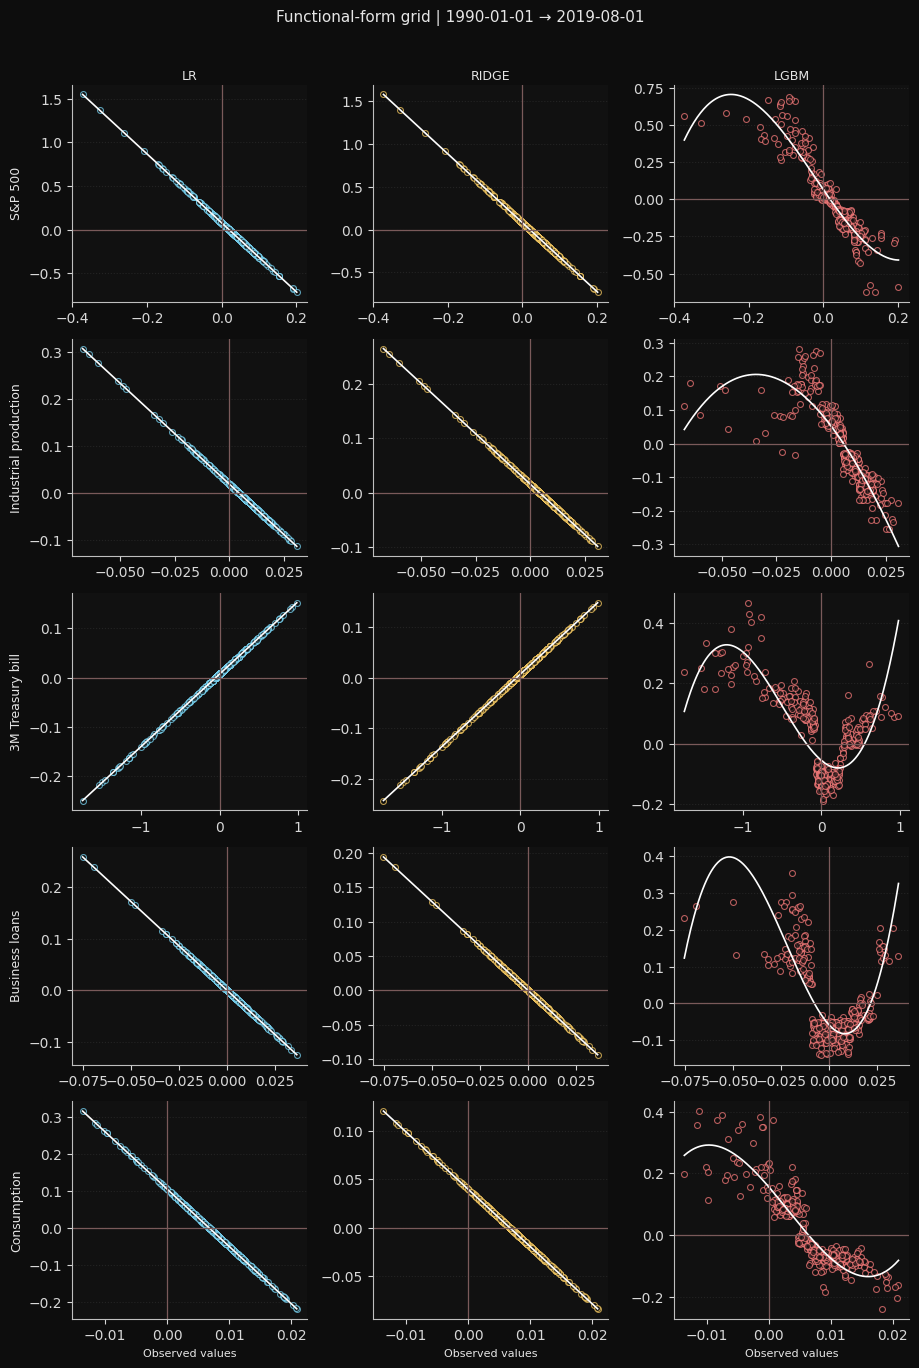

In [40]:
models_dict, X_dict, features_dict = build_functional_inputs_from_meta(
    meta_models=meta_models,
    ts_data=ts_df,
    end_date= end_date,
    date_col="ds",
    model_order=("LR", "RIDGE", "LGBM"),
)

fig, axes = plot_functional_grid(
    models_dict=models_dict,
    X_dict=X_dict,
    selected_vars=selected_vars,
    start_date = start_date,  
    end_date= end_date,
    date_col="ds",
    poly_deg_lgbm=3,
    figsize_per_cell=(3.1, 2.7),
    sharey=False,
    max_n=2000,
    random_state=42,
    _pretty_label_from_feat=_pretty_label_from_feat,
    use_pretty_labels=True,
)

plt.show()

# MLFLOW

In [41]:
# =========================================================
# Préparer les objets pour export MLflow
# à partir de meta_models
# =========================================================

fitted_models = {}
train_fit_dates = {}
features_by_partition = {}
X_by_partition = {}

partitions_all = list(score_df_exp["partition"].astype(str).unique())
model_labels_all = ["LR", "RIDGE", "LGBM"]

for model_label in model_labels_all:
    meta_m = meta_models.get("metas", {}).get(model_label, {})

    fm_list = meta_m.get("fitted_models", None)
    tfd = meta_m.get("train_fit_dates", None)
    feats = meta_m.get("features", None)

    if isinstance(feats, np.ndarray):
        feats = feats.tolist()

    # -----------------------------------------------------
    # train_fit_dates : souvent une liste globale par modèle
    # on la duplique par partition pour le logging
    # -----------------------------------------------------
    for part in partitions_all:
        if tfd is not None:
            train_fit_dates[(model_label, part)] = tfd

        if feats is not None:
            features_by_partition[(model_label, part)] = list(feats)

    # -----------------------------------------------------
    # fitted_models
    # si c'est une liste, on prend le dernier modèle entraîné
    # comme représentant du modèle pour export
    # -----------------------------------------------------
    if isinstance(fm_list, list) and len(fm_list) > 0:
        last_model = fm_list[-1]
        for part in partitions_all:
            fitted_models[(model_label, part)] = last_model

# =========================================================
# Construire X_by_partition
# on réutilise ts_df, filtré jusqu'à la fin de chaque partition
# =========================================================

partition_end_map = {
    "1990-1999": "1999-12-01",
    "2000-2008": "2008-12-01",
    "2009-2019": "2019-12-01",
    "2020-end":  str(pd.Timestamp(EXP_END).to_period("M").to_timestamp(how="start").date()),
    "ALL":       str(pd.Timestamp(EXP_END).to_period("M").to_timestamp(how="start").date()),
}

ts_df_ml = ts_df.copy()
ts_df_ml["ds"] = pd.to_datetime(ts_df_ml["ds"], errors="coerce")
ts_df_ml = ts_df_ml.sort_values("ds").reset_index(drop=True)

for model_label in model_labels_all:
    meta_m = meta_models.get("metas", {}).get(model_label, {})
    feats = meta_m.get("features", None)

    if feats is None:
        continue

    if isinstance(feats, np.ndarray):
        feats = feats.tolist()

    cols_keep = ["ds"] + [c for c in feats if c in ts_df_ml.columns]
    X_model = ts_df_ml.loc[:, cols_keep].copy()

    for part in partitions_all:
        end_p = partition_end_map.get(part, partition_end_map["ALL"])
        end_p = pd.Timestamp(end_p).to_period("M").to_timestamp(how="start")

        X_part = X_model[X_model["ds"] <= end_p].copy()
        X_by_partition[(model_label, part)] = X_part

print("fitted_models:", len(fitted_models))
print("train_fit_dates:", len(train_fit_dates))
print("features_by_partition:", len(features_by_partition))
print("X_by_partition:", len(X_by_partition))

fitted_models: 15
train_fit_dates: 15
features_by_partition: 15
X_by_partition: 15


In [42]:
def my_run_name_fn(row):
    model_label = str(row["model_label"]).upper()
    partition = str(row["partition"]).strip().lower().replace(" ", "_").replace("-", "_")
    return f"02_validation_{model_label}_kfold_{partition}"

In [43]:
log_experiment_runs_to_mlflow(
    score_df_exp=score_df_exp,
    leaderboard_exp=leaderboard_exp,
    bkt_score=bkt_score,
    meta_models=meta_models,

    tracking_uri="http://127.0.0.1:5000",
    experiment_name="Robustness_Test",

    feast_feature_name="stationary_value:value",
    ts_features=exog_cols,

    results_perm_mae_by_part=results_perm_mae_by_part,
    results_perm_deviance_by_part=results_perm_deviance_by_part,
    results_shap_share_by_part=results_shap_share_by_part,

    fitted_models=fitted_models,
    train_fit_dates=train_fit_dates,
    X_by_partition=X_by_partition,
    features_by_partition=features_by_partition,

    run_name_fn=my_run_name_fn,

    # IMPORTANT
    source_dataset_df=ts_df,
    source_dataset_name="stationary_value_value_ts_lag12",
    source_dataset_source="feast:stationary_value:value",

    target_col="UNRATE",
    n_lags=LAGS,
    exog_cols=exog_cols,

    log_mlflow_dataset=True,
    log_mlflow_model=True,
)